# 🏆 고객 이탈 예측 — 모델 학습

> **데이터** : E-Commerce Customer Churn (5,630행 × 20컬럼)  
> **전처리 기반** : `Preprocessing.ipynb` 동일 파이프라인  
> **추가 피처** : 그룹 합성 점수 (GRP_*) · 왜도 구간 피처 (_bin)  
> **모델** : LightGBM · XGBoost + Optuna 하이퍼파라미터 튜닝  
> **목표** : 이탈(Churn=1) 고객 사전 탐지 — **Recall 최대화**

---

| 섹션 | 내용 |
|---|---|
| 1 | 라이브러리 로드 |
| 2 | 전처리 함수 정의 및 파이프라인 실행 |
| 3 | 왜도 변수 구간별 이탈률 분석 (Fig 0) |
| 4 | 그룹 합성 점수 생성 및 피처 확정 |
| 5–6 | LightGBM · XGBoost 학습 |
| 7 | 성능 평가 (지표 테이블 · 분류 리포트) |
| 8 | 시각화 (혼동행렬 · PR · ROC · 피처 중요도) |
| 9 | Top 5 핵심 피처 분석 |
| 10 | 하이퍼파라미터 튜닝 (Optuna) |
| 11 | 최종 평가 리포트 |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve,
    average_precision_score
)
import lightgbm as lgb
import xgboost as xgb

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 120
SEED = 42
print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [2]:
# 데이터 로드
df = pd.read_csv('data/E Commerce Dataset.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [3]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [4]:
df.info()
print()
print(f"원본 데이터: {df.shape[0]:,}행 × {df.shape[1]}컬럼")
print(f"이탈 비율: {df['Churn'].mean()*100:.1f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

## 1. 전처리 함수 정의

전처리 파이프라인을 단계별 함수로 정의합니다.

| 함수 | 역할 | 적용 시점 |
|---|---|---|
| `load_data` | CSV 로드 | - |
| `normalize_categories` | 범주값 통합 | 로드 직후 |
| `fill_missing` | 결측치 처리 | - |
| `handle_outliers` | log1p 변환 | - |
| `encode_features` | One-Hot + Label Encoding | - |
| `split_data` | Train/Val/Test 분리 | - |
| `add_bin_features` | 왜도 큰 변수 → 구간 서열 정수 | **스케일링 전** |
| `scale_features` | StandardScaler | - |
| `add_group_features` | 그룹 합성 점수 컬럼 추가 | **스케일링 후** |
| `preprocess_pipeline` | 전체 파이프라인 실행 | - |

In [5]:
# 전처리 함수 정의

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"[load_data]  {df.shape[0]:,}행 × {df.shape[1]}컬럼  |  이탈율 {df['Churn'].mean()*100:.1f}%")
    return df


def normalize_categories(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})
    df["PreferedOrderCat"]     = df["PreferedOrderCat"].replace({"Mobile Phone": "Mobile"})
    df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace(
        {"Cash on Delivery": "COD", "CC": "Credit Card"}
    )
    print("[normalize_categories]  범주값 통합 완료")
    return df


def fill_missing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    missing_cols = ["DaySinceLastOrder","OrderAmountHikeFromlastYear","Tenure",
                    "OrderCount","CouponUsed","HourSpendOnApp","WarehouseToHome"]
    for col in missing_cols:
        df[col] = df[col].fillna(df[col].mean() if col == "HourSpendOnApp" else df[col].median())
    print(f"[fill_missing]  결측치 처리 완료  |  잔여 NaN: {df.isnull().sum().sum()}개")
    return df


def handle_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["OrderCount_log"] = np.log1p(df["OrderCount"])
    df["CouponUsed_log"] = np.log1p(df["CouponUsed"])
    df = df.drop(columns=["OrderCount","CouponUsed","CustomerID"], errors="ignore")
    print("[handle_outliers]  log1p 변환 완료 (OrderCount_log, CouponUsed_log)")
    return df


def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["CityTier"] = df["CityTier"].astype(str)
    df = pd.get_dummies(df, columns=["CityTier"], prefix="CityTier")
    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)
    df = df.drop(columns=["CityTier_1"], errors="ignore")   # 다중공선성 제거

    cat_cols = ["PreferredLoginDevice","PreferredPaymentMode",
                "Gender","PreferedOrderCat","MaritalStatus"]
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    print(f"[encode_features]  인코딩 완료  |  최종 컬럼 수: {df.shape[1]}개")
    return df


def split_data(df: pd.DataFrame, target: str = "Churn", seed: int = SEED):
    X = df.drop(columns=[target])
    y = df[target]
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, stratify=y, random_state=seed)
    X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed)
    print(f"[split_data]  Train:{len(X_train):,} | Val:{len(X_val):,} | Test:{len(X_test):,}")
    return X_train, X_val, X_test, y_train, y_val, y_test


def scale_features(X_train, X_val, X_test):
    X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()
    num_cols = ["Tenure","WarehouseToHome","HourSpendOnApp","NumberOfDeviceRegistered",
                "SatisfactionScore","NumberOfAddress","OrderAmountHikeFromlastYear",
                "DaySinceLastOrder","CashbackAmount","OrderCount_log","CouponUsed_log"]
    scale_cols = [c for c in num_cols if c in X_train.columns]
    scaler = StandardScaler()
    X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
    X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
    X_test[scale_cols]  = scaler.transform(X_test[scale_cols])
    print(f"[scale_features]  StandardScaler 적용 완료  |  {len(scale_cols)}개 컬럼")
    return X_train, X_val, X_test, scaler


print("✅ 기본 전처리 함수 정의 완료")

✅ 기본 전처리 함수 정의 완료


## 2. 추가 피처 함수 정의

### 2-1. 왜도 구간 피처 함수
> ⚠️ 반드시 **스케일링 전** 원본 스케일 데이터에 적용해야 합니다.

In [6]:
# ── 구간 설정  ────────────────────────
BIN_CONFIGS = {
    "CouponUsed_log": {
        "bins"  : [0, 1, 3, 6, 10, 17],
        "labels": ["0_미사용", "1_낮음", "2_중간", "3_높음", "4_단골"],
        "col_name": "CouponUsed_bin"
    },
    "OrderCount_log": {
        "bins"  : [1, 2, 4, 7, 10, 17],
        "labels": ["0_초기", "1_낮음", "2_중간", "3_높음", "4_단골"],
        "col_name": "OrderCount_bin"
    },
    "WarehouseToHome": {
        "bins"  : [0, 10, 20, 30, 50, 130],
        "labels": ["0_km", "1_10_20km", "2_20_30km", "3_30_50km", "4_50km이상"],
        "col_name": "WarehouseToHome_bin"
    },
    "Tenure": {
        "bins"  : [0, 3, 6, 12, 24, 62],
        "labels": ["0_입문", "1_초기", "2_성장", "3_안정기", "4_장기"],
        "col_name": "Tenure_bin"
    },
}


def add_bin_features(X: pd.DataFrame) -> pd.DataFrame:

    X = X.copy()
    for src_col, cfg in BIN_CONFIGS.items():
        if src_col not in X.columns:
            continue
        binned = pd.cut(
            X[src_col],
            bins=cfg["bins"],
            labels=cfg["labels"],
            include_lowest=True
        )
        # 범주형 → 서열 정수 (0, 1, 2, 3, 4)
        X[cfg["col_name"]] = binned.cat.codes          # NaN이면 -1, 정상이면 0~4
    added = [cfg["col_name"] for cfg in BIN_CONFIGS.values() if cfg["col_name"] in X.columns]
    print(f"[add_bin_features]  구간 피처 추가 완료: {added}")
    return X


print("✅ add_bin_features 정의 완료")

✅ add_bin_features 정의 완료


### 2-2. 변수 그룹핑 합성 점수 함수

In [7]:
# ── 그룹 정의 ──────────────────────────
# CityTier_1 제거 이후 기준: "가계 경제력" 그룹에서 CityTier_1 제외
VAR_GROUPS = {
    "GRP_LifestageRisk": ["MaritalStatus", "Complain"],
    "GRP_PromoGap"  : ["CouponUsed_log", "SatisfactionScore", "Complain"],
    "GRP_TenureFatigue"    : ["Tenure", "Complain"],
    "GRP_LogDistress"      : ["WarehouseToHome", "Complain"],
    "GRP_LoyLockIn"    : ["Tenure", "CashbackAmount","SatisfactionScore"],
    "GRP_LivStability"    : ["CityTier_2", "CityTier_3", "NumberOfAddress"],
    "GRP_PfDep"  : ["DaySinceLastOrder", "OrderCount_log", "CouponUsed_log"],
}


def add_group_features(X_train, X_val, X_test):

    results = []
    for X in [X_train, X_val, X_test]:
        X = X.copy()
        for grp_name, cols in VAR_GROUPS.items():
            exist_cols = [c for c in cols if c in X.columns]
            if len(exist_cols) >= 2:                     # 2개 이상 있을 때만 합성
                X[grp_name] = X[exist_cols].mean(axis=1)
        results.append(X)

    added = [g for g, cols in VAR_GROUPS.items()
             if sum(1 for c in cols if c in results[0].columns) >= 2]
    print(f"[add_group_features]  그룹 피처 추가 완료 ({len(added)}개): {added}")
    return results[0], results[1], results[2]


print("✅ add_group_features 정의 완료")

✅ add_group_features 정의 완료


In [8]:
# 3. 전처리 파이프라인 실행
def preprocess_pipeline(path: str):
    """
    전처리 파이프라인 실행 순서:
    load → normalize → fill_missing → outliers → encode
    → split → [add_bin_features] → scale → return
    ※ add_group_features는 파이프라인 후 별도 호출 (분석 시각화 연계)
    """
    print("=" * 58)
    print("  전처리 파이프라인 시작")
    print("=" * 58)
    df = load_data(path)
    df = normalize_categories(df)
    df = fill_missing(df)
    df = handle_outliers(df)
    df = encode_features(df)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

    # ── bin 피처: 스케일링 전 원본 스케일에서 적용 ─────────────────────
    X_train = add_bin_features(X_train)
    X_val   = add_bin_features(X_val)
    X_test  = add_bin_features(X_test)

    # ── 스케일링 (bin 컬럼은 수치형 목록에 없으므로 자동 제외) ──────────
    X_train, X_val, X_test, scaler = scale_features(X_train, X_val, X_test)

    scale_pw = round((y_train == 0).sum() / (y_train == 1).sum(), 4)
    print(f"[class_weight]  scale_pos_weight = {scale_pw}")
    print("=" * 58)
    print("  ✅ 파이프라인 완료 (그룹 피처는 아래 셀에서 추가)")
    print("=" * 58)
    return X_train, X_val, X_test, y_train, y_val, y_test, scale_pw, scaler




  전처리 파이프라인 시작
[load_data]  5,630행 × 20컬럼  |  이탈율 16.8%
[normalize_categories]  범주값 통합 완료
[fill_missing]  결측치 처리 완료  |  잔여 NaN: 0개
[handle_outliers]  log1p 변환 완료 (OrderCount_log, CouponUsed_log)
[encode_features]  인코딩 완료  |  최종 컬럼 수: 20개
[split_data]  Train:3,378 | Val:1,126 | Test:1,126
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[scale_features]  StandardScaler 적용 완료  |  11개 컬럼
[class_weight]  scale_pos_weight = 4.9367
  ✅ 파이프라인 완료 (그룹 피처는 아래 셀에서 추가)


## 3. 데이터 분리

In [9]:
DATA_PATH = "data/E Commerce Dataset.csv"

df_processed = load_data(DATA_PATH)
df_processed = normalize_categories(df_processed)
df_processed = fill_missing(df_processed)
df_processed = handle_outliers(df_processed)
df_processed = encode_features(df_processed)

X = df_processed.drop(columns=["Churn"])
y = df_processed["Churn"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

# bin 피처 (스케일링 전)
X_train = add_bin_features(X_train)
X_val   = add_bin_features(X_val)
X_test  = add_bin_features(X_test)

# 스케일링
X_train, X_val, X_test, scaler = scale_features(X_train, X_val, X_test)

# 그룹 피처 (스케일링 후)
X_train, X_val, X_test = add_group_features(X_train, X_val, X_test)

scale_pw = round((y_train == 0).sum() / (y_train == 1).sum(), 4)
print(f"scale_pos_weight = {scale_pw}")


[load_data]  5,630행 × 20컬럼  |  이탈율 16.8%
[normalize_categories]  범주값 통합 완료
[fill_missing]  결측치 처리 완료  |  잔여 NaN: 0개
[handle_outliers]  log1p 변환 완료 (OrderCount_log, CouponUsed_log)
[encode_features]  인코딩 완료  |  최종 컬럼 수: 20개
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[scale_features]  StandardScaler 적용 완료  |  11개 컬럼
[add_group_features]  그룹 피처 추가 완료 (7개): ['GRP_LifestageRisk', 'GRP_PromoGap', 'GRP_TenureFatigue', 'GRP_LogDistress', 'GRP_LoyLockIn', 'GRP_LivStability', 'GRP_PfDep']


In [10]:
X_train.columns

Index(['Tenure', 'PreferredLoginDevice', 'WarehouseToHome',
       'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'DaySinceLastOrder', 'CashbackAmount',
       'OrderCount_log', 'CouponUsed_log', 'CityTier_2', 'CityTier_3',
       'CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin',
       'GRP_LifestageRisk', 'GRP_PromoGap', 'GRP_TenureFatigue',
       'GRP_LogDistress', 'GRP_LoyLockIn', 'GRP_LivStability', 'GRP_PfDep'],
      dtype='object')

## 4. 왜도 변수 — 구간별 이탈률 분석 시각화

> 구간(bin)마다 이탈률이 어떻게 달라지는지 확인  
> **스케일링 전 원본 스케일** 데이터 사용

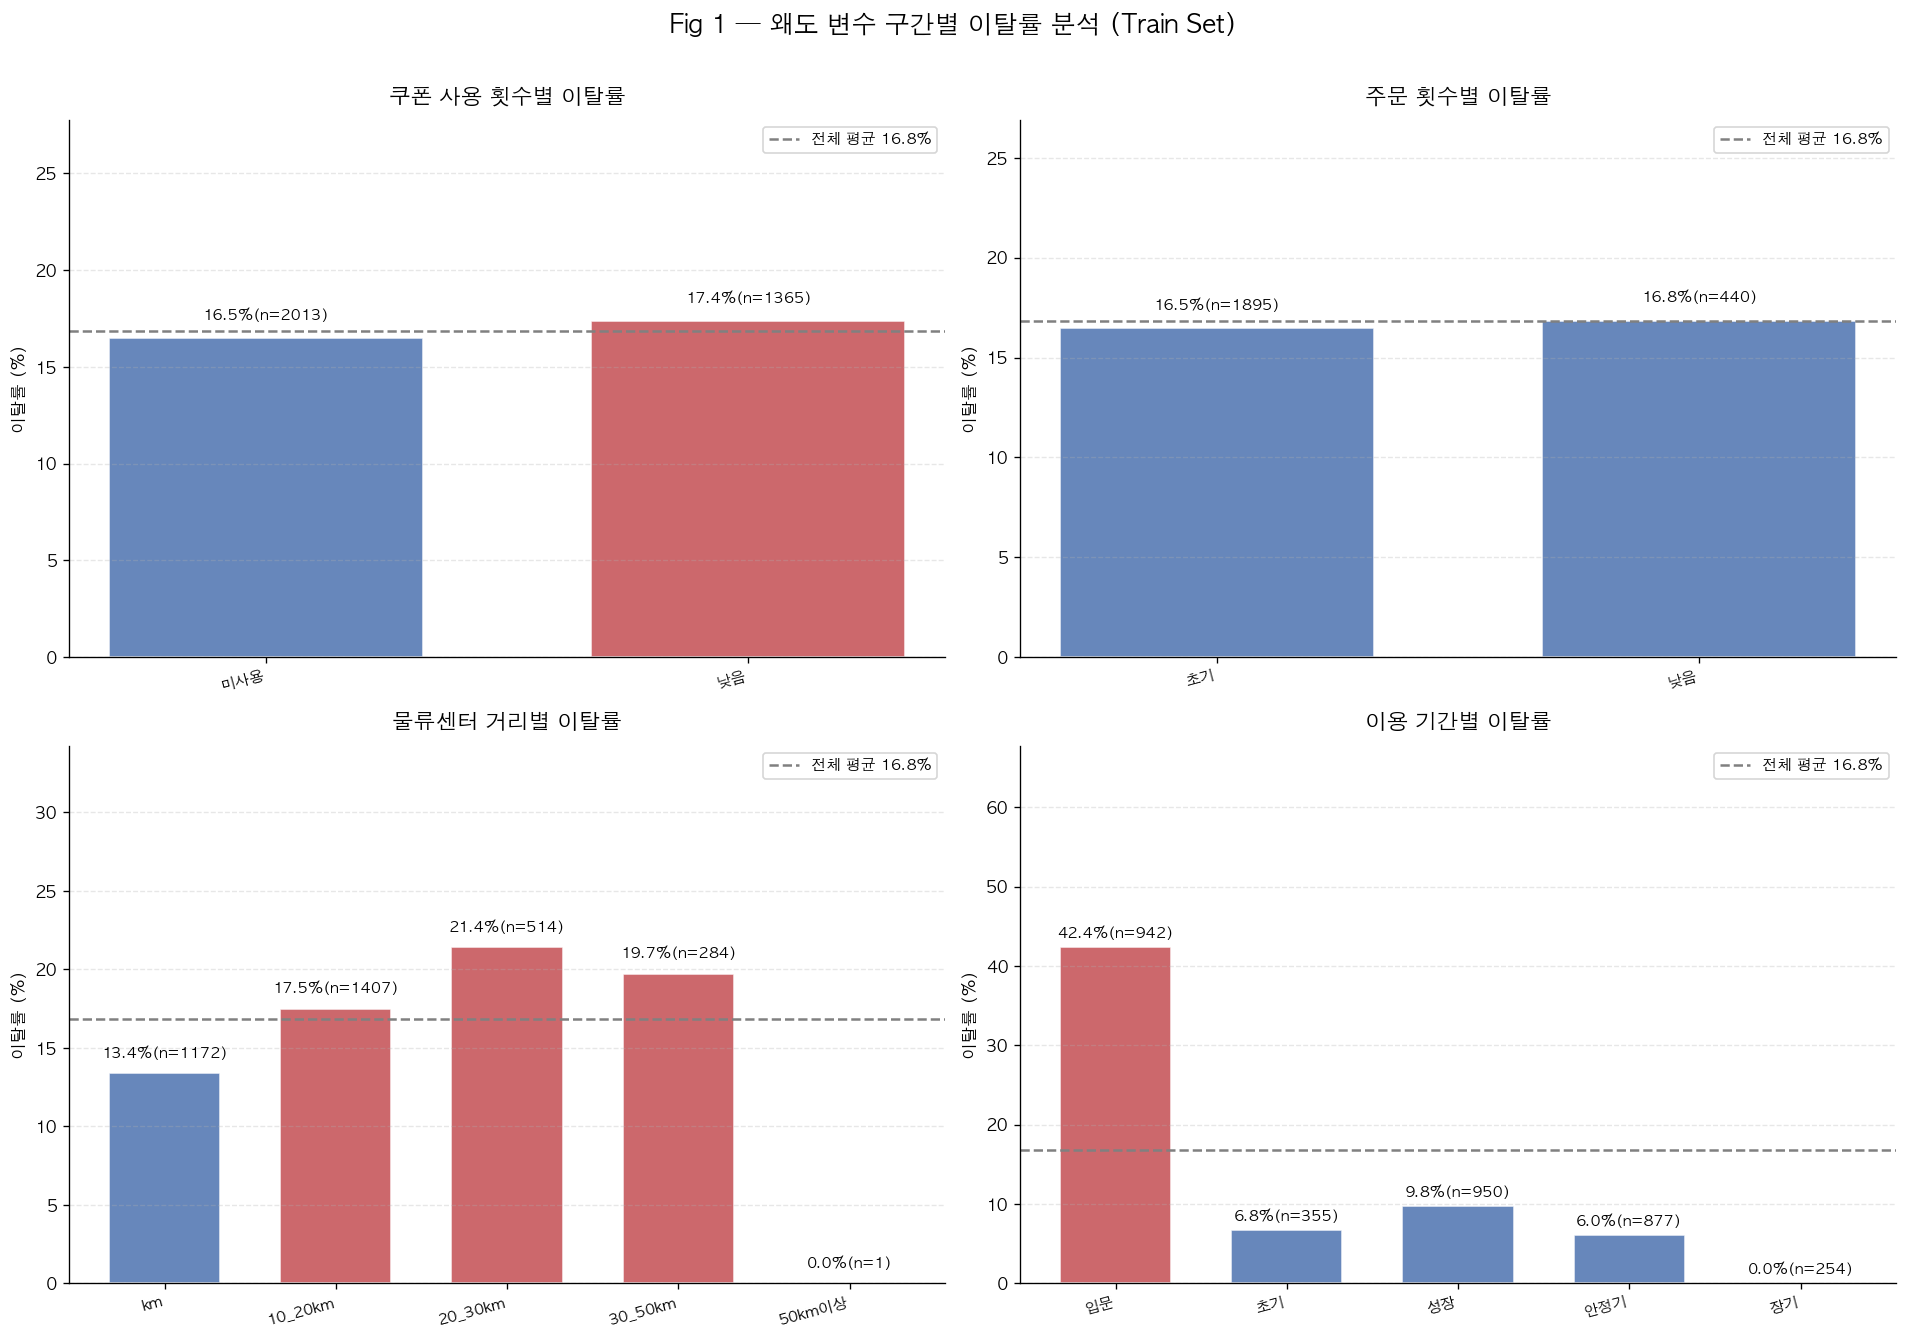

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# 【Fig 1】 왜도 변수 구간별 이탈률 (Churn Rate by Bin)
# ═══════════════════════════════════════════════════════════════════════

# bin 컬럼명 → 원본 bin config 라벨 매핑
BIN_LABELS = {cfg["col_name"]: cfg["labels"] for cfg in BIN_CONFIGS.values()}
BIN_TITLES = {
    "CouponUsed_bin"    : "쿠폰 사용 횟수별 이탈률",
    "OrderCount_bin"    : "주문 횟수별 이탈률",
    "WarehouseToHome_bin": "물류센터 거리별 이탈률",
    "Tenure_bin"        : "이용 기간별 이탈률",
}

overall_churn = y_train.mean()

# 분석용 DataFrame (bin 코드 + Churn)
analysis = X_train[[c for c in X_train.columns if c.endswith("_bin")]].copy()
analysis["Churn"] = y_train.values

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (bin_col, title) in zip(axes, BIN_TITLES.items()):
    if bin_col not in analysis.columns:
        ax.set_visible(False)
        continue

    labels = BIN_LABELS[bin_col]
    # code → 라벨 표시용 문자 (숫자 접두사 제거)
    display_labels = [lbl.split("_", 1)[1] if "_" in lbl else lbl for lbl in labels]

    stats = (analysis
             .groupby(bin_col)["Churn"]
             .agg(["mean","count"])
             .reset_index())
    stats = stats[stats[bin_col] >= 0]   # -1(NaN 코드) 제외

    bar_colors = ["#C44E52" if v > overall_churn else "#4C72B0"
                  for v in stats["mean"]]

    bars = ax.bar(range(len(stats)), stats["mean"] * 100,
                  color=bar_colors, alpha=0.85, edgecolor="white", width=0.65)

    # 전체 평균선
    ax.axhline(overall_churn * 100, color="gray", lw=1.5, ls="--",
               label=f"전체 평균 {overall_churn*100:.1f}%")

    # 값 + 샘플수 레이블
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f"{row['mean']*100:.1f}%(n={int(row['count'])})",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    tick_pos = list(range(len(stats)))
    ax.set_xticks(tick_pos)
    actual_labels = [display_labels[code] for code in stats[bin_col]]
    ax.set_xticklabels(actual_labels, fontsize=9, rotation=15, ha="right")
    ax.set_ylim(0, max(stats["mean"]) * 160)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("이탈률 (%)", fontsize=10)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Fig 1 — 왜도 변수 구간별 이탈률 분석 (Train Set)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. 그룹 합성 점수
### 1. 그룹 합성 점수 피처 추가 

In [12]:
# ── 스케일링 후 그룹 합성 점수 추가 ────────────────────────────────────
print(f"\n 최종 피처 구성  ({X_train.shape[1]}개)")
print()

# 피처 카테고리별 출력
base_cols  = [c for c in X_train.columns if not c.startswith("GRP_") and not c.endswith("_bin")]
bin_cols   = [c for c in X_train.columns if c.endswith("_bin")]
grp_cols   = [c for c in X_train.columns if c.startswith("GRP_")]

print(f"  📌 기본 피처   ({len(base_cols)}개): {base_cols}")
print(f"  📌 구간 피처   ({len(bin_cols)}개): {bin_cols}")
print(f"  📌 그룹 피처   ({len(grp_cols)}개): {grp_cols}")
print(f"\n  ▶ 합계: {len(base_cols) + len(bin_cols) + len(grp_cols)}개")

[add_group_features]  그룹 피처 추가 완료 (7개): ['GRP_LifestageRisk', 'GRP_PromoGap', 'GRP_TenureFatigue', 'GRP_LogDistress', 'GRP_LoyLockIn', 'GRP_LivStability', 'GRP_PfDep']

 최종 피처 구성  (30개)

  📌 기본 피처   (26개): ['Tenure', 'PreferredLoginDevice', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'DaySinceLastOrder', 'CashbackAmount', 'OrderCount_log', 'CouponUsed_log', 'CityTier_2', 'CityTier_3', 'GRP_LifestageRisk', 'GRP_PromoGap', 'GRP_TenureFatigue', 'GRP_LogDistress', 'GRP_LoyLockIn', 'GRP_LivStability', 'GRP_PfDep']
  📌 구간 피처   (4개): ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
  📌 그룹 피처   (0개): []

  ▶ 합계: 30개


### 2. 그룹 합성 점수 - Churn상관관계

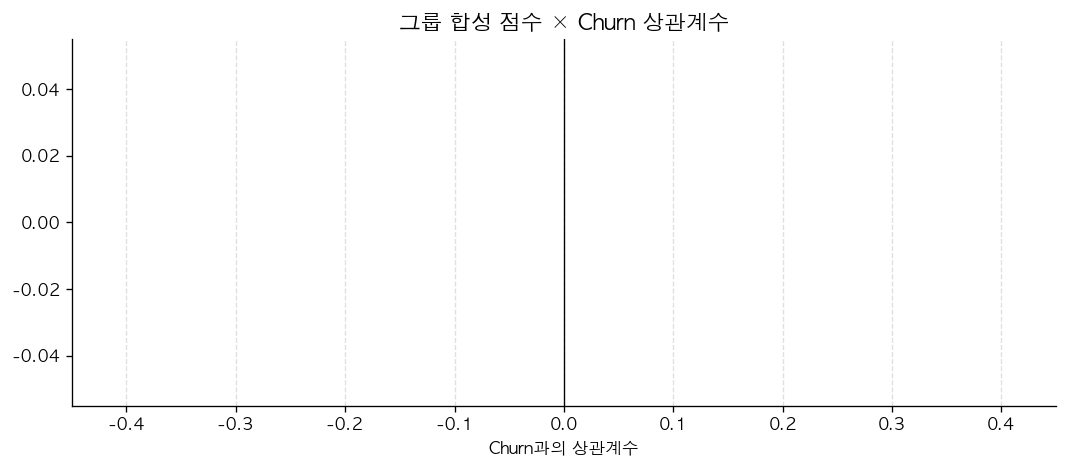

In [13]:
# 시각화
temp_corr = pd.concat([X_train[grp_cols], y_train], axis=1)
group_corr = temp_corr.corr()["Churn"].drop("Churn").sort_values(ascending=False)

# 그룹명 한글 매핑
GRP_KR = {
    "GRP_LifestageRisk": "라이프스테이지 반응성",
    "GRP_PromoGap":      "프로모션·기대 관리",
    "GRP_TenureFatigue": "장기 고객 피로도",
    "GRP_LogDistress":   "물류 경험",
    "GRP_LoyLockIn":     "핵심 충성 고객",
    "GRP_LivStability":  "가계 경제력·거주 환경",
    "GRP_PfDep":         "플랫폼 의존도",
}

fig, ax = plt.subplots(figsize=(9, 4))
colors_g = ["#C44E52" if x > 0 else "#4C72B0" for x in group_corr.values]
labels_kr = [f"{k}\n({GRP_KR.get(k,k)})" for k in group_corr.index]
bars = ax.barh(labels_kr, group_corr.values, color=colors_g, height=0.55, alpha=0.85)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.005 if w >= 0 else w - 0.005, bar.get_y()+bar.get_height()/2,
            f"{w:+.3f}", va="center", ha="left" if w >= 0 else "right",
            fontsize=10, fontweight="bold")

ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(-0.45, 0.45)
ax.set_title("그룹 합성 점수 × Churn 상관계수", fontsize=13, fontweight="bold")
ax.set_xlabel("Churn과의 상관계수", fontsize=10)
ax.grid(axis="x", ls="--", alpha=0.4)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 모델 선정에 있어서 고려한 점

| 피처 유형 | 개수 | 설명 |
|---|---|---|
| 기본 피처 | ~21개 | 전처리 후 원본 피처 |
| 구간 피처 (`_bin`) | 4개 | CouponUsed, OrderCount, WarehouseToHome, Tenure → 서열 정수 |
| 그룹 합성 점수 (`grp_`) | 9개 | 상관관계 기반 변수 그룹 평균 점수 |
| Target data (`Churn`)| 5,630개 | 이진분류(유지(0), 이탈(1)), 정형 데이터, 이탈(1) 비율이 16.8%로 불균형 데이터 |

현재 데이터는 정형 데이터이며 이진분류로 되어있고, 이탈과 유지 비율을 보았을 때 이탈이 16.8%로 불균형적인 데이터이다.<br>
또한, 피처 수가 30개 이상이며, 종류도 다양(원본 수치형 + 범주형 + 그룹 합성 점수 + 구간 피처)하여 성격이 다른 데이터를 처리하고, <br>
불균형 데이터 처리를 위한 기능`scale_pos_weight`이 내장된 트리 계열 모델을 선정함. 

1. 정형 데이터에서 검증된 성능
2. 클래스 불균형 처리 내장
3. 이중 피처 처리 강함
4. 두 모델을 함께 비교한 이유
- LightGBM : Leaf-wise방식으로 소수 클래스 패턴 집중 포착해 Recall(이탈 탐지율)에 강점
- XGBoost : Depth-wise방식으로 균형 잡힌 학습을 통해 전반적인 AUC에 강점

**최종판단 기준** : Accuracy < Recall




## 6. LightGBM 학습

In [14]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, num_leaves=31, max_depth=6,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,
    scale_pos_weight=scale_pw, random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
print(f"✅ LightGBM 완료  |  Best iteration: {lgb_model.best_iteration_}")

✅ LightGBM 완료  |  Best iteration: 442


## 7. XGBoost 학습

In [15]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    min_child_weight=3, scale_pos_weight=scale_pw,
    eval_metric="auc", tree_method="hist", random_state=SEED,
    callbacks=[xgb.callback.EarlyStopping(rounds=50, metric_name="auc", save_best=True)]
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"✅ XGBoost 완료  |  Best iteration: {xgb_model.best_iteration}")

✅ XGBoost 완료  |  Best iteration: 497


## 8. 성능 평가

In [16]:
def find_best_threshold(model, X_val, y_val):
    prob = model.predict_proba(X_val)[:, 1]
    best_th, best_f1 = 0.5, 0.0
    for th in np.arange(0.30, 0.80, 0.01):
        f1 = f1_score(y_val, (prob >= th).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_th = f1, th
    return round(best_th, 2)

def evaluate(model, X, y, label, threshold=0.5):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {"모델": label, "Threshold": threshold,
            "Accuracy" : round(accuracy_score(y, pred), 4),
            "Precision": round(precision_score(y, pred, zero_division=0), 4),
            "Recall"   : round(recall_score(y, pred, zero_division=0), 4),
            "F1"       : round(f1_score(y, pred, zero_division=0), 4),
            "AUC"      : round(roc_auc_score(y, prob), 4)}

lgb_th = find_best_threshold(lgb_model, X_val, y_val)
xgb_th = find_best_threshold(xgb_model, X_val, y_val)
print(f"LightGBM 최적 임계값: {lgb_th}  |  XGBoost 최적 임계값: {xgb_th}")

LightGBM 최적 임계값: 0.39  |  XGBoost 최적 임계값: 0.35


In [17]:
# 성능 비교 테이블
results = [
    evaluate(lgb_model, X_val,  y_val,  "LightGBM  Val",  lgb_th),
    evaluate(lgb_model, X_test, y_test, "LightGBM  Test", lgb_th),
    evaluate(xgb_model, X_val,  y_val,  "XGBoost   Val",  xgb_th),
    evaluate(xgb_model, X_test, y_test, "XGBoost   Test", xgb_th),
]
result_df = pd.DataFrame(results).set_index("모델")
display(result_df.style
    .format({"Threshold":"{:.2f}","Accuracy":"{:.4f}","Precision":"{:.4f}",
             "Recall":"{:.4f}","F1":"{:.4f}","AUC":"{:.4f}"})
    .highlight_max(subset=["Accuracy","Precision","Recall","F1","AUC"], color="#c8f0c8")
    .set_caption("📊 모델 성능 비교 (초록=최고값)"))

,Threshold,Accuracy,Precision,Recall,F1,AUC
모델,,,,,,
LightGBM Val,0.39,0.9316,0.7897,0.8105,0.8000,0.9475
LightGBM Test,0.39,0.9458,0.7909,0.9206,0.8509,0.9735
XGBoost Val,0.35,0.9272,0.7523,0.8474,0.7970,0.9460
XGBoost Test,0.35,0.9343,0.7386,0.9418,0.8279,0.9713


In [18]:
# 모델 성능비교 리포트 
for model, name, th in [(lgb_model,"LightGBM",lgb_th),(xgb_model,"XGBoost",xgb_th)]:
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= th).astype(int)
    rep  = classification_report(y_test, pred, target_names=["유지(0)","이탈(1)"], output_dict=True)
    df_r = pd.DataFrame(rep).T
    df_r["support"] = df_r["support"].astype(int)
    print(f"\n{'='*50}\n  {name}  (threshold={th})\n{'='*50}")
    display(df_r.style
        .format({"precision":"{:.4f}","recall":"{:.4f}","f1-score":"{:.4f}","support":"{:.0f}"})
        .highlight_max(subset=["precision","recall","f1-score"], color="#c8f0c8")
        .set_caption(f"{name} — Classification Report (Test Set)"))


  LightGBM  (threshold=0.39)


,precision,recall,f1-score,support
유지(0),0.9834,0.9509,0.9669,937
이탈(1),0.7909,0.9206,0.8509,189
accuracy,0.9458,0.9458,0.9458,0
macro avg,0.8872,0.9358,0.9089,1126
weighted avg,0.9511,0.9458,0.9474,1126



  XGBoost  (threshold=0.35)


,precision,recall,f1-score,support
유지(0),0.9876,0.9328,0.9594,937
이탈(1),0.7386,0.9418,0.8279,189
accuracy,0.9343,0.9343,0.9343,0
macro avg,0.8631,0.9373,0.8936,1126
weighted avg,0.9458,0.9343,0.9373,1126


## 9. 시각화
### 1. 혼동행렬

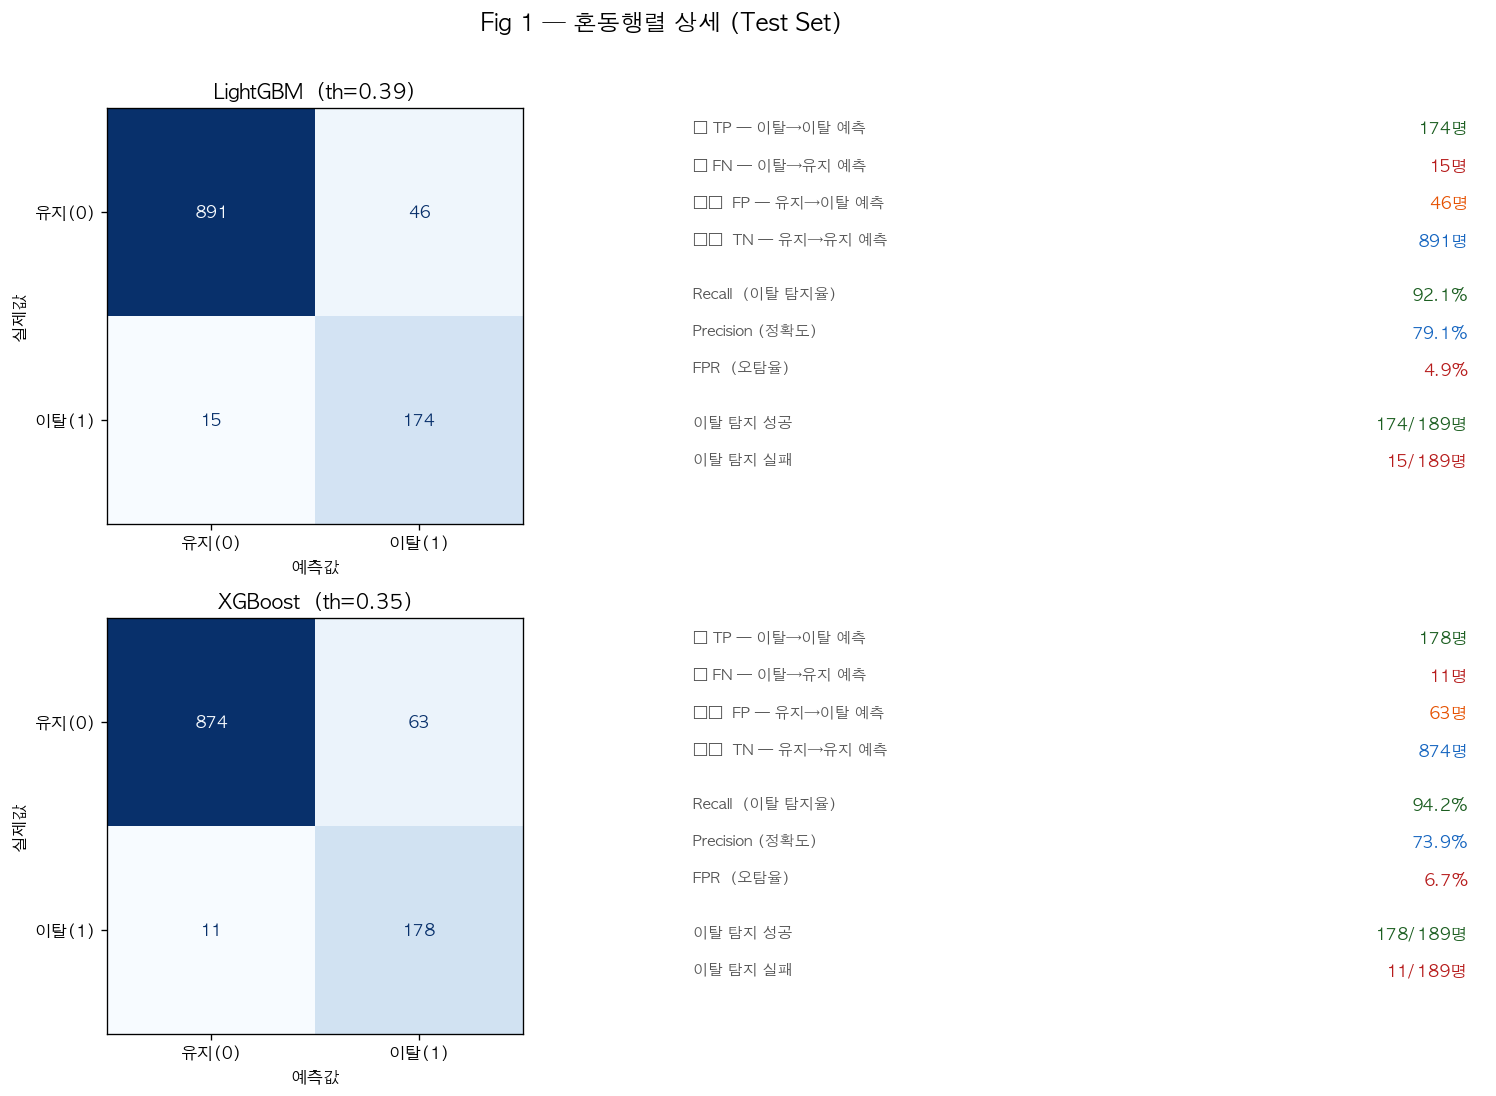

In [19]:
def plot_cm_panel(model, X, y, name, th, ax_cm, ax_info):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= th).astype(int)
    cm   = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()

    ConfusionMatrixDisplay(cm, display_labels=["유지(0)","이탈(1)"]).plot(
        ax=ax_cm, colorbar=False, cmap="Blues", values_format="d")
    ax_cm.set_title(f"{name}  (th={th})", fontsize=12, fontweight="bold")
    ax_cm.set_xlabel("예측값"); ax_cm.set_ylabel("실제값")

    ax_info.axis("off")
    rec   = tp/(tp+fn) if (tp+fn)>0 else 0
    prec  = tp/(tp+fp) if (tp+fp)>0 else 0
    fpr_v = fp/(fp+tn) if (fp+tn)>0 else 0
    items = [
        ("✅ TP — 이탈→이탈 예측",  f"{tp:,}명", "#1B5E20"),
        ("❌ FN — 이탈→유지 예측",  f"{fn:,}명", "#B71C1C"),
        ("⚠️  FP — 유지→이탈 예측", f"{fp:,}명", "#E65100"),
        ("✔️  TN — 유지→유지 예측",  f"{tn:,}명", "#1565C0"),
        ("", "", ""),
        ("Recall  (이탈 탐지율)",    f"{rec*100:.1f}%",  "#1B5E20"),
        ("Precision (정확도)",               f"{prec*100:.1f}%", "#1565C0"),
        ("FPR  (오탐율)",            f"{fpr_v*100:.1f}%","#B71C1C"),
        ("", "", ""),
        (f"이탈 탐지 성공", f"{tp}/{y.sum():.0f}명", "#1B5E20"),
        (f"이탈 탐지 실패", f"{fn}/{y.sum():.0f}명", "#B71C1C"),
    ]
    y_pos = 0.97
    for label, val, color in items:
        if not label: y_pos -= 0.04; continue
        ax_info.text(0.02, y_pos, label, transform=ax_info.transAxes,
                     fontsize=9, va="top", color="#555")
        ax_info.text(0.98, y_pos, val,   transform=ax_info.transAxes,
                     fontsize=10, va="top", ha="right", fontweight="bold", color=color)
        y_pos -= 0.09

fig, axes = plt.subplots(2, 2, figsize=(14, 9),
                          gridspec_kw={"width_ratios":[1,0.85]})
plot_cm_panel(lgb_model, X_test, y_test, "LightGBM", lgb_th, axes[0][0], axes[0][1])
plot_cm_panel(xgb_model, X_test, y_test, "XGBoost",  xgb_th, axes[1][0], axes[1][1])
plt.suptitle("Fig 1 — 혼동행렬 상세 (Test Set)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 2. AUC-ROC 곡선

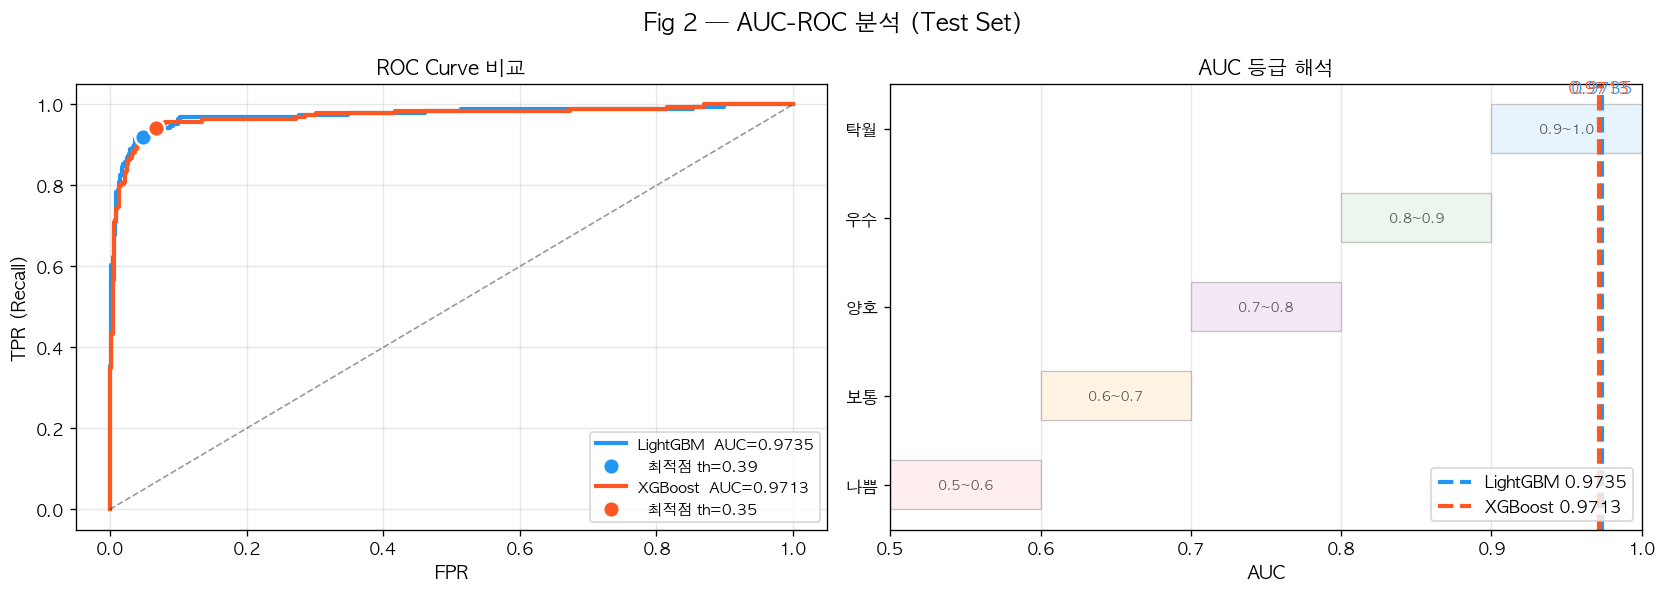

In [20]:
# ════════════════════════════════════════════════════════
# 【Fig 2】 AUC-ROC  Curve (Test Set)
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
C = {"LightGBM":"#2196F3","XGBoost":"#FF5722"}

# ── 왼쪽: ROC 비교 ────────────────────────────────────────────────
ax = axes[0]
for model, name, th in [(lgb_model,"LightGBM",lgb_th),(xgb_model,"XGBoost",xgb_th)]:
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_v = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2.5, color=C[name], label=f"{name}  AUC={auc_v:.4f}")
    # 최적 임계값 점
    fpr_th = ((model.predict_proba(X_test)[:,1]>=th)&(y_test==0)).sum()/(y_test==0).sum()
    tpr_th = ((model.predict_proba(X_test)[:,1]>=th)&(y_test==1)).sum()/(y_test==1).sum()
    ax.scatter(fpr_th, tpr_th, s=100, color=C[name], zorder=5,
               edgecolors="white", lw=1.5, label=f"  최적점 th={th}")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
ax.set_xlabel("FPR",fontsize=11); ax.set_ylabel("TPR (Recall)",fontsize=11)
ax.set_title("ROC Curve 비교", fontsize=12, fontweight="bold")
ax.legend(fontsize=9,loc="lower right"); ax.grid(alpha=0.3)


# ── 오른쪽: AUC 등급 가이드 ──────────────────────────────────────
ax2 = axes[1]
bands = [(0.5,0.6,"#ffebee","나쁨"),(0.6,0.7,"#fff3e0","보통"),
         (0.7,0.8,"#f3e5f5","양호"),(0.8,0.9,"#e8f5e9","우수"),(0.9,1.0,"#e3f2fd","탁월")]
for lo,hi,clr,lbl in bands:
    ax2.barh(lbl,hi-lo,left=lo,height=0.55,color=clr,edgecolor="#bbb",lw=0.8,alpha=0.85)
    ax2.text((lo+hi)/2,lbl,f"{lo:.1f}~{hi:.1f}",ha="center",va="center",fontsize=8,color="#555")
for name,model in [("LightGBM",lgb_model),("XGBoost",xgb_model)]:
    auc_v = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    ax2.axvline(auc_v,color=C[name],lw=2.5,ls="--",label=f"{name} {auc_v:.4f}")
    ax2.text(auc_v,4.4,f"{auc_v:.4f}",ha="center",fontsize=10,fontweight="bold",color=C[name])
ax2.set_xlim(0.5,1.0); ax2.set_xlabel("AUC",fontsize=11)
ax2.set_title("AUC 등급 해석",fontsize=12,fontweight="bold")
ax2.legend(fontsize=10,loc="lower right"); ax2.grid(axis="x",alpha=0.3)

plt.suptitle("Fig 2 — AUC-ROC 분석 (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 3. PR 곡선 & 임계값 민감도

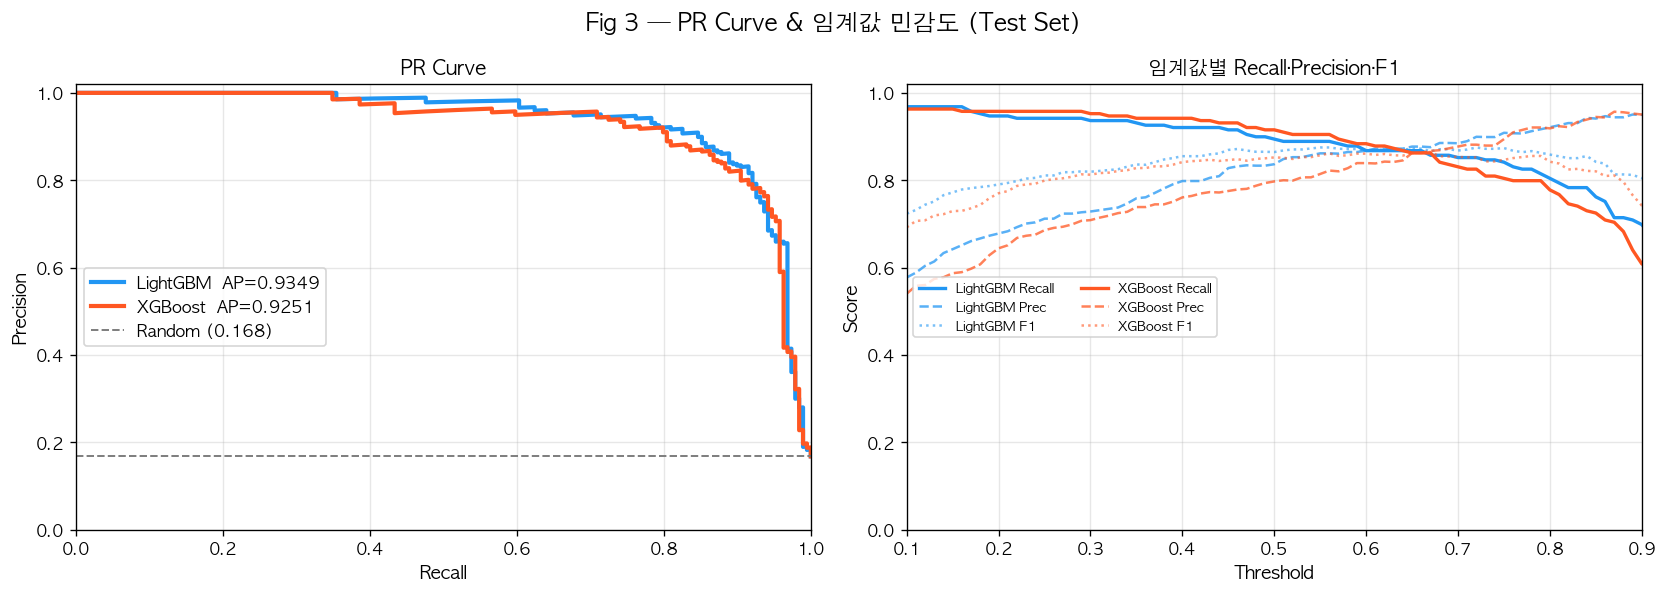

In [21]:
# ════════════════════════════════════════════════════════
# 【Fig 3】 PR 곡선 & 임계값 민감도
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 왼쪽: PR 곡선 ────────────────────────────────────────────────
ax = axes[0]
for model, name in [(lgb_model,"LightGBM"),(xgb_model,"XGBoost")]:
    prob = model.predict_proba(X_test)[:,1]
    prec_c, rec_c, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec_c, prec_c, lw=2.5, color=C[name], label=f"{name}  AP={ap:.4f}")
ax.axhline(y_test.mean(), color="gray", lw=1.2, ls="--",
           label=f"Random ({y_test.mean():.3f})")
ax.set_xlabel("Recall",fontsize=11); ax.set_ylabel("Precision",fontsize=11)
ax.set_title("PR Curve", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_xlim(0,1); ax.set_ylim(0,1.02)

# ── 오른쪽: 임계값별 지표 변화 ───────────────────────────────────
ax2 = axes[1]
ths = np.arange(0.1, 0.95, 0.01)
for model, name, color in [(lgb_model,"LightGBM","#2196F3"),(xgb_model,"XGBoost","#FF5722")]:
    prob = model.predict_proba(X_test)[:,1]
    recs,precs,f1s = [],[],[]
    for t in ths:
        pred = (prob>=t).astype(int)
        recs.append(recall_score(y_test,pred,zero_division=0))
        precs.append(precision_score(y_test,pred,zero_division=0))
        f1s.append(f1_score(y_test,pred,zero_division=0))
    ax2.plot(ths,recs, lw=2,   color=color, ls="-",  label=f"{name} Recall")
    ax2.plot(ths,precs,lw=1.5, color=color, ls="--", label=f"{name} Prec",  alpha=0.75)
    ax2.plot(ths,f1s,  lw=1.5, color=color, ls=":",  label=f"{name} F1",    alpha=0.6)
ax2.set_xlabel("Threshold",fontsize=11); ax2.set_ylabel("Score",fontsize=11)
ax2.set_title("임계값별 Recall·Precision·F1",fontsize=12,fontweight="bold")
ax2.legend(fontsize=8,ncol=2,loc="center left"); ax2.grid(alpha=0.3)
ax2.set_xlim(0.1,0.9); ax2.set_ylim(0,1.02)

plt.suptitle("Fig 3 — PR Curve & 임계값 민감도 (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 4. Feature Importance Top-10 비교

- 전처리에서 feature를 구간화, 그룹화 하였는데 그것들이 중요한 지 확인

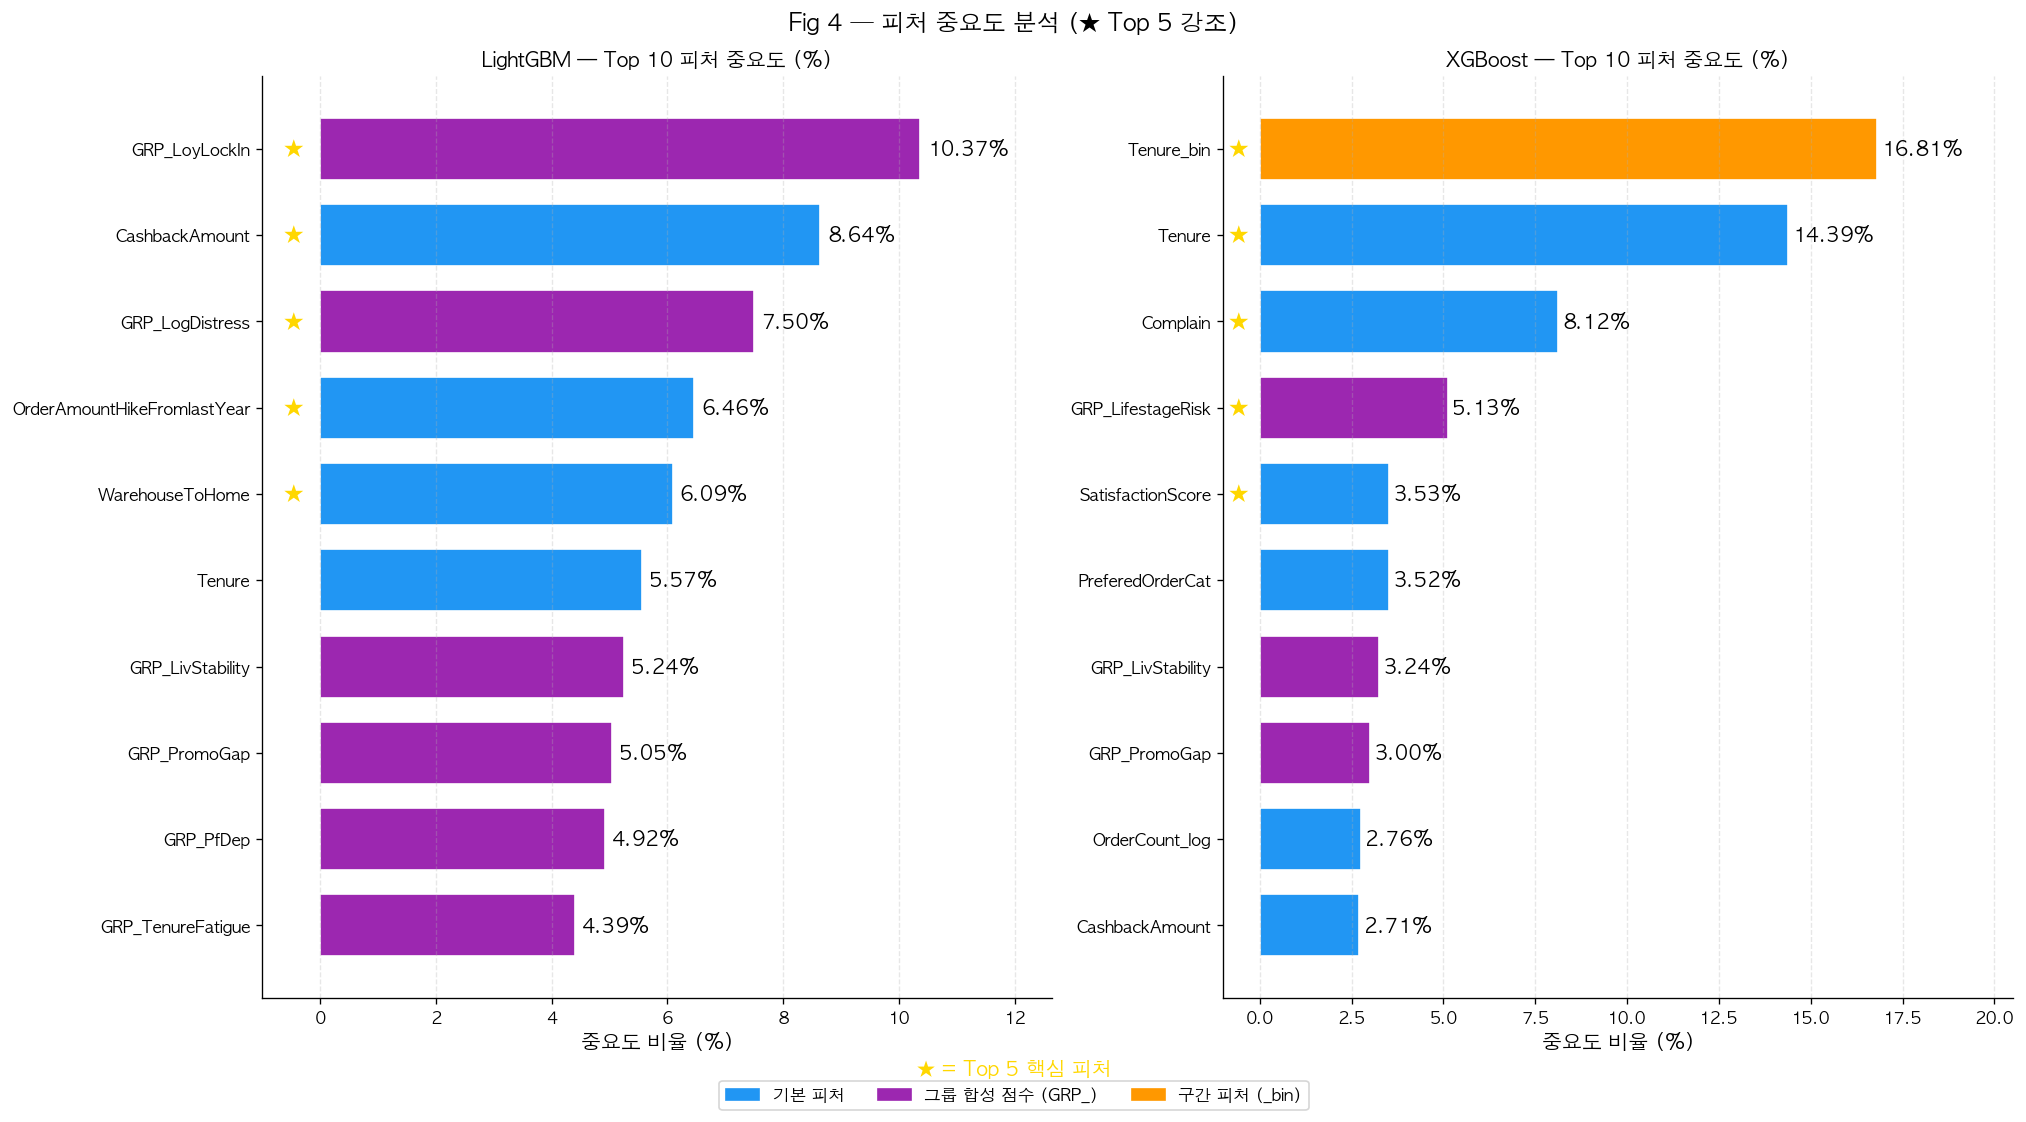

In [22]:
# ════════════════════════════════════════════════════════
# 【Fig 4】 Feature Importance Top-10 비교
# ════════════════════════════════════════════════════════
def feat_color(col):
    if col.startswith("GRP_"): return "#9C27B0"   # 보라: 그룹
    if col.endswith("_bin"):   return "#FF9800"   # 주황: 구간
    return "#2196F3"                               # 파랑: 기본

TOP_N = 10
fi_data = {
    "LightGBM": pd.Series(lgb_model.feature_importances_, index=X_train.columns)
                  .pipe(lambda s: s/s.sum()*100).nlargest(TOP_N),
    "XGBoost" : pd.Series(xgb_model.feature_importances_, index=X_train.columns)
                  .pipe(lambda s: s/s.sum()*100).nlargest(TOP_N),
}

fig, axes = plt.subplots(1, 2, figsize=(17, 9))
for ax, (name, fi) in zip(axes, fi_data.items()):
    fi_s = fi.sort_values(ascending=True)
    top5 = fi.nlargest(5).index.tolist()
    colors_b = [feat_color(c) for c in fi_s.index]

    bars = ax.barh(fi_s.index, fi_s.values, color=colors_b, edgecolor="white", height=0.72)
    for bar, col, val in zip(bars, fi_s.index, fi_s.values):
        ax.text(val+0.12, bar.get_y()+bar.get_height()/2,
                f"{val:.2f}%", va="center", ha="left", fontsize=12)
        if col in top5:
            ax.text(-0.3, bar.get_y()+bar.get_height()/2,
                    "★", va="center", ha="right", fontsize=13, color="#FFD700", fontweight="bold")

    ax.set_xlim(-1, fi_s.max()*1.22)
    ax.set_title(f"{name} — Top {TOP_N} 피처 중요도 (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("중요도 비율 (%)",fontsize=12)
    ax.grid(axis="x",alpha=0.3,ls="--"); ax.spines[["top","right"]].set_visible(False)

legend_h = [mpatches.Patch(color="#2196F3",label="기본 피처"),
            mpatches.Patch(color="#9C27B0",label="그룹 합성 점수 (GRP_)"),
            mpatches.Patch(color="#FF9800",label="구간 피처 (_bin)")]
fig.text(0.5,-0.005,"★ = Top 5 핵심 피처",ha="center",fontsize=12,color="#FFD700",fontweight="bold")
fig.legend(handles=legend_h,loc="lower center",ncol=3,fontsize=10,bbox_to_anchor=(0.5,-0.045))
plt.suptitle("Fig 4 — 피처 중요도 분석 (★ Top 5 강조)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

In [23]:
# Feature Importance TOP 5 핵심 feature 분석
lgb_fi_full = pd.Series(lgb_model.feature_importances_, index=X_train.columns).pipe(lambda s: s/s.sum()*100)
xgb_fi_full = pd.Series(xgb_model.feature_importances_, index=X_train.columns).pipe(lambda s: s/s.sum()*100)

all_feats = list(set(lgb_fi_full.nlargest(5).index) | set(xgb_fi_full.nlargest(5).index))
rows_t5 = []
for feat in all_feats:
    lgb_r = list(lgb_fi_full.rank(ascending=False).astype(int))[list(lgb_fi_full.index).index(feat)]
    xgb_r = list(xgb_fi_full.rank(ascending=False).astype(int))[list(xgb_fi_full.index).index(feat)]
    rows_t5.append({
        "피처": feat,
        "유형": "그룹" if feat.startswith("GRP_") else ("구간" if feat.endswith("_bin") else "기본"),
        "LGB 중요도(%)": round(lgb_fi_full[feat],2),
        "LGB 순위": lgb_r,
        "XGB 중요도(%)": round(xgb_fi_full[feat],2),
        "XGB 순위": xgb_r,
        "통합순위": lgb_r + xgb_r,
    })

top5_df = (pd.DataFrame(rows_t5).sort_values("통합순위")
           .head(5).reset_index(drop=True))
top5_df.index += 1; top5_df.index.name = "순위"

display(top5_df.style
    .format({"LGB 중요도(%)":"{:.2f}","XGB 중요도(%)":"{:.2f}"})
    .bar(subset=["LGB 중요도(%)"],color="#90CAF9")
    .bar(subset=["XGB 중요도(%)"],color="#FFAB91")
    .set_caption("📊 통합 Top 5 핵심 피처"))

print("\n🔑 핵심 피처 비즈니스 해석:")
interp = {
    "Tenure":         "이용 기간 — 짧을수록 이탈 위험 ↑ (신규 고객 온보딩 핵심)",
    "Complain":       "불만 접수 여부 — 가장 직접적인 이탈 신호",
    "DaySinceLastOrder": "마지막 주문 공백 — 길수록 이탈 위험 ↑",
    "CashbackAmount": "캐시백 혜택 — 클수록 이탈 억제 효과",
    "SatisfactionScore": "만족도 점수 — 낮을수록 이탈 위험",
    "GRP_TenureFatigue": "장기 고객 피로도 그룹 — Tenure+Complain 복합 신호",
    "GRP_LoyLockIn":     "핵심 충성 그룹 — Tenure+CashbackAmount+Satisfaction 복합",
    "GRP_LifestageRisk": "라이프스테이지 반응성 — MaritalStatus+Complain 복합",
    "Tenure_bin":        "이용 기간 구간 — 0-3개월(입문기) 이탈 집중",
}
for i, row in top5_df.iterrows():
    print(f"  {i}위. {row['피처']:<28} → {interp.get(row['피처'],'—')}")

,피처,유형,LGB 중요도(%),LGB 순위,XGB 중요도(%),XGB 순위,통합순위
순위,,,,,,,
1,Tenure,기본,5.57,6,14.39,2,8
2,CashbackAmount,기본,8.64,2,2.71,10,12
3,SatisfactionScore,기본,2.61,16,3.53,5,21
4,GRP_LifestageRisk,그룹,1.82,18,5.13,4,22
5,GRP_LogDistress,그룹,7.50,3,1.93,21,24



🔑 핵심 피처 비즈니스 해석:
  1위. Tenure                       → 이용 기간 — 짧을수록 이탈 위험 ↑ (신규 고객 온보딩 핵심)
  2위. CashbackAmount               → 캐시백 혜택 — 클수록 이탈 억제 효과
  3위. SatisfactionScore            → 만족도 점수 — 낮을수록 이탈 위험
  4위. GRP_LifestageRisk            → 라이프스테이지 반응성 — MaritalStatus+Complain 복합
  5위. GRP_LogDistress              → —


## 10. 하이퍼파라미터 튜닝 (Optuna)

### 1. 모델 선정 근거

**LightGBM · XGBoost를 최종 튜닝 대상으로 선정한 이유**

두 모델은 이 데이터의 조건(5,630행, 수치+범주 혼합, 16.8% 클래스 불균형, GRP_/bin 합성 피처 포함)에서 Tree-based Ensemble 계열 중 가장 검증된 알고리즘이다.

| 기준 | LightGBM | XGBoost |
|---|---|---|
| 학습 방식 | Leaf-wise — 복잡한 비선형 경계 포착 | Depth-wise — 안정적 일반화 |
| 불균형 처리 | `scale_pos_weight` 손실 함수 반영 | 동일 |
| 그룹·구간 피처 대응 | 트리 기반 — 스케일 무관, 상호작용 자동 포착 | 동일 |
| 기존 AUC | 0.975 | **0.976** |
| 기존 Recall | **0.905** | 0.900 |


### 2. 튜닝 파라미터 선정 근거

#### LightGBM

| 파라미터 | 탐색 범위 | 선정 이유 |
|---|---|---|
| `num_leaves` | 20–150 | Leaf-wise 핵심 복잡도 제어 — GRP_/bin 피처 추가로 탐색 범위 확대 |
| `max_depth` | 3–10 | `num_leaves` 과성장 억제 |
| `learning_rate` | 0.01–0.20 | Early stopping 사용 → 작은 lr도 실용적 |
| `subsample` | 0.6–1.0 | 행 샘플링 — 노이즈 완화 |
| `colsample_bytree` | 0.6–1.0 | 피처 샘플링 — 합성 피처 다양성 확보 |
| `reg_alpha` | 1e-4–5.0 | L1 — GRP_/bin 불필요 가중치 압축 |
| `reg_lambda` | 1e-4–5.0 | L2 — 가중치 크기 안정화 |
| `min_child_samples` | 10–80 | 소수 클래스(이탈) 과적합 방지 핵심 |

#### XGBoost

| 파라미터 | 탐색 범위 | 선정 이유 |
|---|---|---|
| `max_depth` | 3–9 | 트리 깊이 — 복잡도와 일반화 균형 |
| `learning_rate` | 0.01–0.20 | 동일 |
| `subsample` | 0.6–1.0 | 동일 |
| `colsample_bytree` | 0.6–1.0 | 동일 |
| `reg_alpha` | 1e-4–5.0 | 동일 |
| `reg_lambda` | 1e-4–5.0 | 동일 |
| `min_child_weight` | 1–20 | 리프 최소 가중치 — 이탈 소수 클래스 안정 학습 |
| `gamma` | 0–1.0 | 불필요 분기 차단 — 합성 피처 과분기 방지 |

> **최적화 기준** : Validation AUC 최대화  
> **탐색기** : Optuna TPE Sampler (50 trials / 모델)  
> **조기 종료** : 각 trial 내 early stopping 50 라운드

In [24]:
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","optuna","-q"], check=True)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"✅ Optuna {optuna.__version__}")

✅ Optuna 4.8.0


## 11.하이퍼파라미터 튜닝
### 11-1. LightGBM Optuna 튜닝

In [25]:
def lgb_objective(trial):
    p = dict(
        n_estimators     = 1000,
        num_leaves       = trial.suggest_int("num_leaves", 20, 150),
        max_depth        = trial.suggest_int("max_depth", 3, 10),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        min_child_samples= trial.suggest_int("min_child_samples", 10, 80),
        scale_pos_weight = scale_pw,
        random_state=SEED, n_jobs=-1, verbose=-1,
    )
    m = lgb.LGBMClassifier(**p)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])

print("🔍 LightGBM 탐색 시작 (50 trials)...")
lgb_study = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ LightGBM 튜닝 완료  |  Best Val AUC: {lgb_study.best_value:.4f}")
print("   Best Params:")
for k,v in lgb_study.best_params.items():
    print(f"     {k:<22}: {v}")

🔍 LightGBM 탐색 시작 (50 trials)...


Best trial: 25. Best value: 0.949381: 100%|██████████| 50/50 [03:55<00:00,  4.71s/it]


✅ LightGBM 튜닝 완료  |  Best Val AUC: 0.9494
   Best Params:
     num_leaves            : 84
     max_depth             : 9
     learning_rate         : 0.022779969794500088
     subsample             : 0.8529552529953792
     colsample_bytree      : 0.7389479413612069
     reg_alpha             : 0.0009749160888964944
     reg_lambda            : 0.0005251219034192072
     min_child_samples     : 31


### 11-2. XGBoost Optuna 튜닝

In [26]:
def xgb_objective(trial):
    p = dict(
        n_estimators     = 1000,
        max_depth        = trial.suggest_int("max_depth", 3, 9),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 20),
        gamma            = trial.suggest_float("gamma", 0.0, 1.0),
        scale_pos_weight = scale_pw,
        eval_metric="auc", tree_method="hist", random_state=SEED,
        callbacks=[xgb.callback.EarlyStopping(rounds=50,metric_name="auc",save_best=True)],
    )
    m = xgb.XGBClassifier(**p)
    m.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])

print("🔍 XGBoost 탐색 시작 (50 trials)...")
xgb_study = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ XGBoost 튜닝 완료  |  Best Val AUC: {xgb_study.best_value:.4f}")
print("   Best Params:")
for k,v in xgb_study.best_params.items():
    print(f"     {k:<22}: {v}")

🔍 XGBoost 탐색 시작 (50 trials)...


Best trial: 35. Best value: 0.950613: 100%|██████████| 50/50 [00:48<00:00,  1.02it/s]


✅ XGBoost 튜닝 완료  |  Best Val AUC: 0.9506
   Best Params:
     max_depth             : 6
     learning_rate         : 0.13585326204529252
     subsample             : 0.932878388483052
     colsample_bytree      : 0.8040306844961173
     reg_alpha             : 0.09254118616616781
     reg_lambda            : 0.0002997936538322769
     min_child_weight      : 2
     gamma                 : 0.10351262498245851


### 11-3. 최적 파라미터로 재학습

In [27]:
lgb_best = lgb.LGBMClassifier(
    **lgb_study.best_params, n_estimators=1000,
    scale_pos_weight=scale_pw, random_state=SEED, n_jobs=-1, verbose=-1)
lgb_best.fit(X_train, y_train, eval_set=[(X_val,y_val)],
             callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])

xgb_best = xgb.XGBClassifier(
    **xgb_study.best_params, n_estimators=1000,
    scale_pos_weight=scale_pw, eval_metric="auc", tree_method="hist", random_state=SEED,
    callbacks=[xgb.callback.EarlyStopping(rounds=50,metric_name="auc",save_best=True)])
xgb_best.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)

lgb_best_th = find_best_threshold(lgb_best, X_val, y_val)
xgb_best_th = find_best_threshold(xgb_best, X_val, y_val)
print(f"✅ LightGBM 재학습  |  iter:{lgb_best.best_iteration_}  th:{lgb_best_th}")
print(f"✅ XGBoost  재학습  |  iter:{xgb_best.best_iteration}  th:{xgb_best_th}")

✅ LightGBM 재학습  |  iter:500  th:0.45
✅ XGBoost  재학습  |  iter:196  th:0.32


### 11-4. 튜닝 전후 성능 비교

In [28]:
cmp_rows = [
    {**evaluate(lgb_model, X_test, y_test, "LightGBM (튜닝 전)", lgb_th),       "구분":"전"},
    {**evaluate(lgb_best,  X_test, y_test, "LightGBM (튜닝 후)", lgb_best_th),  "구분":"후"},
    {**evaluate(xgb_model, X_test, y_test, "XGBoost  (튜닝 전)", xgb_th),       "구분":"전"},
    {**evaluate(xgb_best,  X_test, y_test, "XGBoost  (튜닝 후)", xgb_best_th),  "구분":"후"},
]
cmp_df = pd.DataFrame(cmp_rows).set_index("모델")
display(cmp_df.style
    .format({"Threshold":"{:.2f}","Accuracy":"{:.4f}","Precision":"{:.4f}",
             "Recall":"{:.4f}","F1":"{:.4f}","AUC":"{:.4f}"})
    .highlight_max(subset=["Accuracy","Precision","Recall","F1","AUC"],color="#c8f0c8")
    .set_caption("📊 튜닝 전후 성능 비교"))

,Threshold,Accuracy,Precision,Recall,F1,AUC,구분
모델,,,,,,,
LightGBM (튜닝 전),0.39,0.9458,0.7909,0.9206,0.8509,0.9735,전
LightGBM (튜닝 후),0.45,0.9503,0.8182,0.9048,0.8593,0.9733,후
XGBoost (튜닝 전),0.35,0.9343,0.7386,0.9418,0.8279,0.9713,전
XGBoost (튜닝 후),0.32,0.9476,0.7955,0.9259,0.8557,0.9746,후


### 11-5. 튜닝 전후 막대 비교 + Optuna 탐색 이력

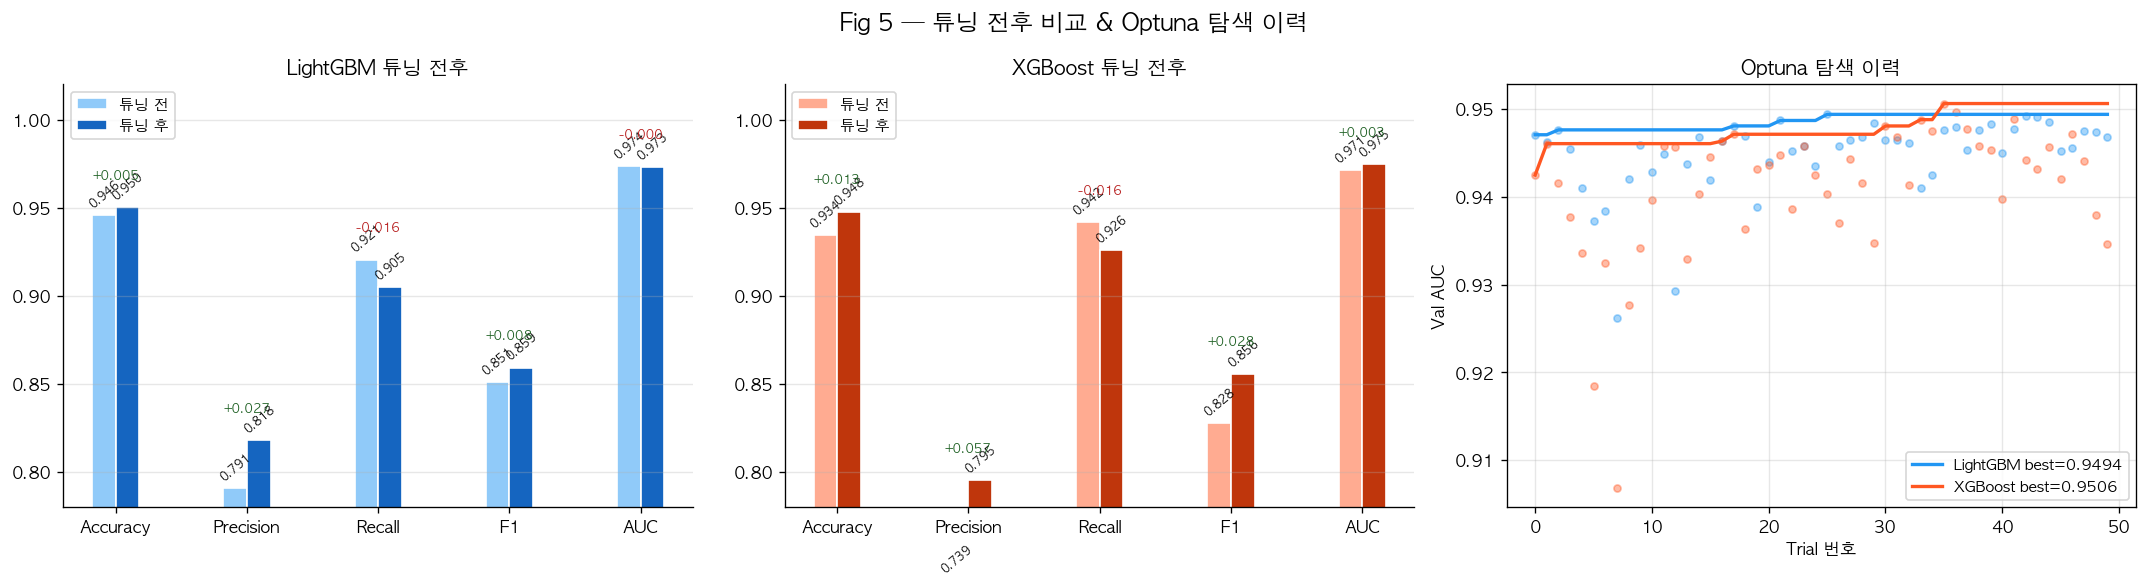

In [29]:
# ════════════════════════════════════════════════════════
# 【Fig 5】 튜닝 전후 막대 비교 + Optuna 탐색 이력
# ════════════════════════════════════════════════════════
metrics = ["Accuracy","Precision","Recall","F1","AUC"]
x = np.arange(len(metrics))
w = 0.18

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 왼쪽 2개: 모델별 전후 비교 ───────────────────────────────────
cfgs = [
    ("LightGBM",lgb_model,lgb_th,lgb_best,lgb_best_th,"#90CAF9","#1565C0"),
    ("XGBoost", xgb_model,xgb_th,xgb_best,xgb_best_th,"#FFAB91","#BF360C"),
]
for ax,(name,bm,bth,am,ath,cb,ca) in zip(axes[:2],cfgs):
    bv = [evaluate(bm,X_test,y_test,"",bth)[m] for m in metrics]
    av = [evaluate(am,X_test,y_test,"",ath)[m] for m in metrics]
    r1 = ax.bar(x-w/2,bv,w,label="튜닝 전",color=cb,edgecolor="white")
    r2 = ax.bar(x+w/2,av,w,label="튜닝 후",color=ca,edgecolor="white")
    for rect,val in zip(list(r1)+list(r2),bv+av):
        ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.003,
                f"{val:.3f}",ha="center",va="bottom",fontsize=7,rotation=40)
    for i,(b,a) in enumerate(zip(bv,av)):
        d=a-b; clr="#1B5E20" if d>0 else "#B71C1C"
        ax.annotate(f"{d:+.3f}",xy=(i,max(b,a)+0.016),ha="center",fontsize=7.5,color=clr,fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(metrics,fontsize=10)
    ax.set_ylim(0.78,1.02)
    ax.set_title(f"{name} 튜닝 전후",fontsize=12,fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y",alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

# ── 오른쪽: Optuna 탐색 이력 ──────────────────────────────────────
ax3 = axes[2]
for study,name,color in [(lgb_study,"LightGBM","#2196F3"),(xgb_study,"XGBoost","#FF5722")]:
    tr = study.trials_dataframe()
    ax3.scatter(tr["number"],tr["value"],c=color,s=18,alpha=0.4)
    ax3.plot(tr["number"],tr["value"].cummax(),color=color,lw=2,label=f"{name} best={study.best_value:.4f}")
ax3.set_xlabel("Trial 번호",fontsize=10); ax3.set_ylabel("Val AUC",fontsize=10)
ax3.set_title("Optuna 탐색 이력",fontsize=12,fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.suptitle("Fig 5 — 튜닝 전후 비교 & Optuna 탐색 이력",fontsize=14,fontweight="bold")
plt.tight_layout(); plt.show()

## 최종 평가 리포트

 📋 고객 이탈 예측 모델 — 최종 평가 리포트 (튜닝 후)                  ║
╠══════════════════════════════════════════════════════════════════════╣
║  평가 데이터 : Test Set ({len(y_test):,}명 | 이탈 {churn_n}명)            ║
╠══════════════════════════════════════════════════════════════════════╣
║  [ 튜닝 후 성능 비교 ]                                                   ║
║                                                                      ║
║   지표        LightGBM (th={lgb_best_th})      XGBoost  (th={xgb_best_th})║
║  ──────────────────────────────────────────────────────────────────  ║
║   Accuracy  {lgb_m['acc']:.4f}                  {xgb_m['acc']:.4f}
║   Precision {lgb_m['prec']:.4f}                  {xgb_m['prec']:.4f}
║   Recall  ★ {lgb_m['rec']:.4f}                  {xgb_m['rec']:.4f}
║   F1-Score  {lgb_m['f1']:.4f}                  {xgb_m['f1']:.4f}
║   ROC-AUC   {lgb_m['auc']:.4f}                  {xgb_m['auc']:.4f}
║   Avg Prec  {lgb_m['ap']:.4f}                  {xgb_m['ap']:.4f}
║
╠══════════════════════════════════════════════════════════════════════╣
║  [ 최종 추천 모델 : {winner} ]
║
║  ✅ 이탈 탐지 성공 : {int(w['tp']):,}명 / {churn_n}명  ({w['tp']/churn_n*100:.1f}%)
║  ❌ 이탈 탐지 실패 : {int(w['fn']):,}명 / {churn_n}명  ({w['fn']/churn_n*100:.1f}%)
║  ⚠️  정상→이탈 오탐: {int(w['fp']):,}명
║


 [ 핵심 이탈 신호 (Top 5 피처 기반) ]
 1. Tenure          — 이용 기간 짧을수록 이탈 ↑
 2. Complain        — 불만 접수 = 가장 강력한 이탈 선행 신호
 3. DaySinceLastOrder — 주문 공백이 길수록 이탈 ↑
 4. GRP_TenureFatigue — Tenure+Complain 복합 피로도
 5. CashbackAmount  — 캐시백 혜택 = 이탈 방어 핵심

 [ 비즈니스 액션 ]
 • 입문기(0–3개월) 고객 → 온보딩 강화 프로그램
 • Complain=1 고객 → 즉시 CS 인터벤션
 • 주문 공백 14일+ → 리텐션 쿠폰 자동 발송
 • 캐시백 혜택 확대 → 충성 고객 Lock-in

In [30]:
def full_metrics(model, X, y, th):
    prob = model.predict_proba(X)[:,1]
    pred = (prob>=th).astype(int)
    cm   = confusion_matrix(y,pred)
    tn,fp,fn,tp = cm.ravel()
    return dict(acc=accuracy_score(y,pred), prec=precision_score(y,pred,zero_division=0),
                rec=recall_score(y,pred,zero_division=0), f1=f1_score(y,pred,zero_division=0),
                auc=roc_auc_score(y,prob), ap=average_precision_score(y,prob),
                tp=tp,fp=fp,fn=fn,tn=tn)

# 튜닝 후 모델 기준
lgb_m = full_metrics(lgb_best, X_test, y_test, lgb_best_th)
xgb_m = full_metrics(xgb_best, X_test, y_test, xgb_best_th)

winner = "LightGBM" if lgb_m["rec"] >= xgb_m["rec"] else "XGBoost"
w, w_th = (lgb_m, lgb_best_th) if winner=="LightGBM" else (xgb_m, xgb_best_th)
churn_n = int(y_test.sum())

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║           📋 고객 이탈 예측 모델 — 최종 평가 리포트 (튜닝 후)                  ║
╠══════════════════════════════════════════════════════════════════════╣
║  평가 데이터 : Test Set ({len(y_test):,}명 | 이탈 {churn_n}명)            ║
╠══════════════════════════════════════════════════════════════════════╣
║  [ 튜닝 후 성능 비교 ]                                                   ║
║                                                                      ║
║   지표        LightGBM (th={lgb_best_th})      XGBoost  (th={xgb_best_th})║
║  ──────────────────────────────────────────────────────────────────  ║
║   Accuracy  {lgb_m['acc']:.4f}                  {xgb_m['acc']:.4f}
║   Precision {lgb_m['prec']:.4f}                  {xgb_m['prec']:.4f}
║   Recall  ★ {lgb_m['rec']:.4f}                  {xgb_m['rec']:.4f}
║   F1-Score  {lgb_m['f1']:.4f}                  {xgb_m['f1']:.4f}
║   ROC-AUC   {lgb_m['auc']:.4f}                  {xgb_m['auc']:.4f}
║   Avg Prec  {lgb_m['ap']:.4f}                  {xgb_m['ap']:.4f}
║
╠══════════════════════════════════════════════════════════════════════╣
║  [ 최종 추천 모델 : {winner} ]
║
║  ✅ 이탈 탐지 성공 : {int(w['tp']):,}명 / {churn_n}명  ({w['tp']/churn_n*100:.1f}%)
║  ❌ 이탈 탐지 실패 : {int(w['fn']):,}명 / {churn_n}명  ({w['fn']/churn_n*100:.1f}%)
║  ⚠️  정상→이탈 오탐: {int(w['fp']):,}명
║
╚══════════════════════════════════════════════════════════════════════╝""")


╔══════════════════════════════════════════════════════════════════════╗
║           📋 고객 이탈 예측 모델 — 최종 평가 리포트 (튜닝 후)                  ║
╠══════════════════════════════════════════════════════════════════════╣
║  평가 데이터 : Test Set (1,126명 | 이탈 189명)            ║
╠══════════════════════════════════════════════════════════════════════╣
║  [ 튜닝 후 성능 비교 ]                                                   ║
║                                                                      ║
║   지표        LightGBM (th=0.45)      XGBoost  (th=0.32)║
║  ──────────────────────────────────────────────────────────────────  ║
║   Accuracy  0.9503                  0.9476
║   Precision 0.8182                  0.7955
║   Recall  ★ 0.9048                  0.9259
║   F1-Score  0.8593                  0.8557
║   ROC-AUC   0.9733                  0.9746
║   Avg Prec  0.9314                  0.9325
║
╠══════════════════════════════════════════════════════════════════════╣
║  [ 최종 추천 모델 : XGBoost ]
║
║  ✅ 이탈 탐지 성공 : 